## imports

In [1]:
import os
import torch
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt

from PIL import Image
from typing import List, Dict


## Load CIFAR-10 seed images

In [2]:
os.makedirs("data/images", exist_ok=True)

dataset = torchvision.datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=T.ToTensor(),
)

class_names = dataset.classes
print("Classes:", class_names)


Files already downloaded and verified
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## Save seed images

In [3]:
SEED_IMAGES = []

for i in range(10):
    img_tensor, label = dataset[i]
    img = T.ToPILImage()(img_tensor)

    path = f"data/images/img_{i}_{class_names[label]}.png"
    img.save(path)
    SEED_IMAGES.append((path, class_names[label]))

print("Saved seed images:")
for p, l in SEED_IMAGES:
    print(p, "→", l)


Saved seed images:
data/images/img_0_frog.png → frog
data/images/img_1_truck.png → truck
data/images/img_2_truck.png → truck
data/images/img_3_deer.png → deer
data/images/img_4_automobile.png → automobile
data/images/img_5_automobile.png → automobile
data/images/img_6_bird.png → bird
data/images/img_7_horse.png → horse
data/images/img_8_ship.png → ship
data/images/img_9_cat.png → cat


## Visualize seeds

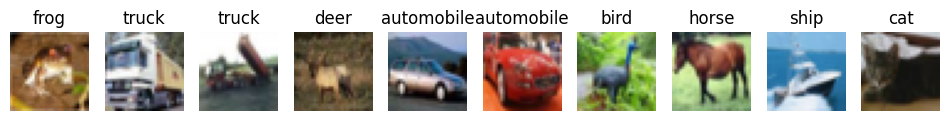

In [4]:
plt.figure(figsize=(12, 3))
for i, (path, label) in enumerate(SEED_IMAGES):
    plt.subplot(1, len(SEED_IMAGES), i + 1)
    plt.imshow(Image.open(path))
    plt.title(label)
    plt.axis("off")
plt.show()


## IMAGE → CAPTION

In [5]:
from transformers import BlipProcessor, BlipForConditionalGeneration

device = "cuda" if torch.cuda.is_available() else "cpu"

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(device)


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

In [6]:
def caption_image(image_path: str) -> str:
    image = Image.open(image_path).convert("RGB")
    inputs = processor(image, return_tensors="pt").to(device)

    out = model.generate(**inputs, max_new_tokens=50)
    caption = processor.decode(out[0], skip_special_tokens=True)

    return caption


## Generate accurate captions

In [7]:
CAPTIONS = {}

for path, label in SEED_IMAGES:
    caption = caption_image(path)
    CAPTIONS[path] = caption

    print(f"\n🖼 {os.path.basename(path)}")
    print("Caption:", caption)



🖼 img_0_frog.png
Caption: a small white dog with a green collar

🖼 img_1_truck.png
Caption: a truck with a large trailer on the back

🖼 img_2_truck.png
Caption: a tractor is parked on the road

🖼 img_3_deer.png
Caption: a light shining in the dark sky

🖼 img_4_automobile.png
Caption: a white car driving down a road with mountains in the background

🖼 img_5_automobile.png
Caption: a red car in a showroom

🖼 img_6_bird.png
Caption: an elephant and a bird walking down the road

🖼 img_7_horse.png
Caption: a horse in a field with trees in the background

🖼 img_8_ship.png
Caption: a white boat in the ocean with a blue sky

🖼 img_9_cat.png
Caption: a black cat laying on the floor


## CAPTION AUGMENTATION (TEXT-ONLY LLM — NeMo)

In [8]:
from openai import OpenAI
from nemo_curator import OpenAIClient
from nemo_curator.synthetic import NemotronGenerator

openai_client = OpenAI(
    base_url=os.environ["NVIDIA_BASE_URL"],
    api_key=os.environ["NVIDIA_API_KEY"],
)

curator_client = OpenAIClient(openai_client)
generator = NemotronGenerator(curator_client)

MODEL = "mistralai/mistral-7b-instruct-v0.3"

MODEL_KWARGS = {
    "temperature": 0.7,
    "top_p": 0.9,
    "max_tokens": 150,
}


In [9]:
def augment_caption(caption: str) -> List[str]:
    prompt = f"""
    Generate 3 diverse, detailed variations of this image caption
    for synthetic image generation.

    Caption:
    "{caption}"

    Return each variation on a new line.
    """

    response = curator_client.query_model(
        model=MODEL,
        messages=[{"role": "user", "content": prompt}],
        **MODEL_KWARGS,
    )[0]

    return [line.strip("- ").strip() for line in response.split("\n") if line.strip()]


In [10]:
AUGMENTED_CAPTIONS = {}

for path, base_caption in CAPTIONS.items():
    augmented = augment_caption(base_caption)
    AUGMENTED_CAPTIONS[path] = augmented

    print("\nBase:", base_caption)
    for a in augmented:
        print("  →", a)



Base: a small white dog with a green collar
  → 1. "A tiny, snowy-white canine, adorned with a vibrant green collar, captures the eye in this captivating image."
  → 2. "In the heart of the frame, a petite, purebred white dog is seen, its collar a striking shade of green, adding a burst of color to the scene."
  → 3. "The focus of this image is a delicate, white puppy, its neck graced by a green collar that stands out against its pristine fur, creating a charming contrast."

Base: a truck with a large trailer on the back
  → 1. "A colossal truck, adorned with a massive trailer, dominates the scene, creating an impressive sight."
  → 2. "In the foreground, a mighty truck with an expansive trailer attached to its rear stands imposingly, showcasing its grandeur."
  → 3. "A powerful semi-truck, accompanied by a spacious trailer, stretches out across the landscape, demonstrating the dominance of modern transportation."

Base: a tractor is parked on the road
  → 1. "A lone tractor, its whee

## TEXT → IMAGE (DIFFUSION)

In [12]:
import os
import torch
from diffusers import StableDiffusionPipeline

# Increase HF download timeouts
os.environ["HF_HUB_DOWNLOAD_TIMEOUT"] = "300"
os.environ["HF_HUB_ETAG_TIMEOUT"] = "300"

model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    resume_download=True
)

device = "cuda" if torch.cuda.is_available() else "cpu"
pipe = pipe.to(device)

os.makedirs("data/synthetic", exist_ok=True)



Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/492M [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Keyword arguments {'resume_download': True} are not expected by StableDiffusionPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


## Generate synthetic images

In [13]:
img_id = 0

for path, captions in AUGMENTED_CAPTIONS.items():
    for caption in captions:
        image = pipe(caption, num_inference_steps=30).images[0]

        out_path = f"data/synthetic/synth_{img_id}.png"
        image.save(out_path)

        print("Generated:", out_path)
        img_id += 1


  0%|          | 0/30 [00:00<?, ?it/s]

Generated: data/synthetic/synth_0.png


  0%|          | 0/30 [00:00<?, ?it/s]

Generated: data/synthetic/synth_1.png


  0%|          | 0/30 [00:00<?, ?it/s]

...

Generated: data/synthetic/synth_27.png


  0%|          | 0/30 [00:00<?, ?it/s]

Generated: data/synthetic/synth_28.png


  0%|          | 0/30 [00:00<?, ?it/s]

Generated: data/synthetic/synth_29.png


## SEE a generated image

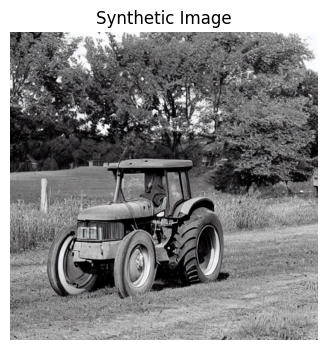

In [17]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("data/synthetic/synth_8.png")

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis("off")
plt.title("Synthetic Image")
plt.show()


## save metadata alongside images

In [18]:
import json
import os

metadata = []
img_id = 0

for seed_path, captions in AUGMENTED_CAPTIONS.items():

    # Extract class from seed filename (img_X_class.png)
    seed_filename = os.path.basename(seed_path)
    seed_class = seed_filename.split("_")[-1].replace(".png", "")

    base_caption = CAPTIONS[seed_path]

    for caption in captions:
        image = pipe(caption, num_inference_steps=30).images[0]

        img_name = f"synth_{img_id}.png"
        out_path = os.path.join("data/synthetic", img_name)
        image.save(out_path)

        record = {
            "synthetic_image": img_name,
            "seed_image": seed_filename,
            "class": seed_class,
            "base_caption": base_caption,
            "augmented_caption": caption,
            "generator": "stable-diffusion-v1-5",
            "num_inference_steps": 30
        }

        metadata.append(record)
        print("Generated:", out_path)

        img_id += 1


  0%|          | 0/30 [00:00<?, ?it/s]

Generated: data/synthetic/synth_0.png


  0%|          | 0/30 [00:00<?, ?it/s]

Generated: data/synthetic/synth_1.png


  0%|          | 0/30 [00:00<?, ?it/s]

...

Generated: data/synthetic/synth_27.png


  0%|          | 0/30 [00:00<?, ?it/s]

Generated: data/synthetic/synth_28.png


  0%|          | 0/30 [00:00<?, ?it/s]

Generated: data/synthetic/synth_29.png


## Save metadata to disk

In [19]:
with open("data/synthetic/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved metadata.json with", len(metadata), "entries")


Saved metadata.json with 30 entries


## Group synthetic images by class

In [20]:
import shutil

for record in metadata:
    cls = record["class"]
    img_name = record["synthetic_image"]

    class_dir = os.path.join("data/synthetic", cls)
    os.makedirs(class_dir, exist_ok=True)

    src = os.path.join("data/synthetic", img_name)
    dst = os.path.join(class_dir, img_name)

    if os.path.exists(src):
        shutil.move(src, dst)


## Update metadata paths

In [21]:
for record in metadata:
    record["synthetic_image"] = f"{record['class']}/{record['synthetic_image']}"

with open("data/synthetic/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)


In [22]:
IMAGES_PER_CLASS = 200   # 10 classes → 2000 images


## Expand captions per class

In [23]:
from itertools import cycle

SCALED_CAPTIONS = {}

for seed_path, augmented in AUGMENTED_CAPTIONS.items():
    seed_filename = os.path.basename(seed_path)
    seed_class = seed_filename.split("_")[-1].replace(".png", "")

    SCALED_CAPTIONS.setdefault(seed_class, [])
    SCALED_CAPTIONS[seed_class].extend(augmented)
